In [1]:
id = 7

In [2]:
pID = 'sub-' + "%01d" % (id)

import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import cross_val_score, KFold

import pickle, json, os
import scipy.io

from bci_funcs import bandpass_filter_fft, average_power_fft, calculate_velocity, gaze_remove_invalid_samples

path = 'P:\\Lukas_Gehrke\\NAH\\data\\5_single-subject-EEG-analysis'
# path = '/Users/lukasgehrke/data/NAH/data/5_single-subject-EEG-analysis/'

# Explore Behavior

In [3]:
behavior = pd.read_csv(path+os.sep+pID+os.sep+'behavior_s'+str(id)+'.csv', sep=';')

In [4]:
behavior = behavior[behavior.bad_epoch != 1]

In [5]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for AccuracyCm
Q1_AccuracyCm = behavior['AccuracyCm'].quantile(0.25)
Q3_AccuracyCm = behavior['AccuracyCm'].quantile(0.75)

# Calculate IQR for AccuracyCm
IQR_AccuracyCm = Q3_AccuracyCm - Q1_AccuracyCm

# Define the lower and upper bounds for outliers in AccuracyCm
lower_bound_AccuracyCm = Q1_AccuracyCm - 1.5 * IQR_AccuracyCm
upper_bound_AccuracyCm = Q3_AccuracyCm + 1.5 * IQR_AccuracyCm

# Calculate Q1 (25th percentile) and Q3 (75th percentile) for fix_delay
Q1_fix_delay = behavior['fix_delay'].quantile(0.25)
Q3_fix_delay = behavior['fix_delay'].quantile(0.75)

# Calculate IQR for fix_delay
IQR_fix_delay = Q3_fix_delay - Q1_fix_delay

# Define the lower and upper bounds for outliers in fix_delay
lower_bound_fix_delay = Q1_fix_delay - 1.5 * IQR_fix_delay
upper_bound_fix_delay = Q3_fix_delay + 1.5 * IQR_fix_delay

# # Filter out the outliers
# behavior_filt = behavior[
#     (behavior['AccuracyCm'] >= lower_bound_AccuracyCm) & (behavior['AccuracyCm'] <= upper_bound_AccuracyCm) &
#     (behavior['fix_delay'] >= lower_bound_fix_delay) & (behavior['fix_delay'] <= upper_bound_fix_delay)
# ]

# Filter out the outliers
behavior_filt = behavior[
    (behavior['AccuracyCm'] >= lower_bound_AccuracyCm) & (behavior['AccuracyCm'] <= upper_bound_AccuracyCm)
]

# print both behavior and behavior_filt shape with some text
print('Behavior shape:', behavior.shape)
print('Behavior_filt shape:', behavior_filt.shape)

behavior = behavior_filt

Behavior shape: (137, 13)
Behavior_filt shape: (136, 13)


C:\Users\Lukas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


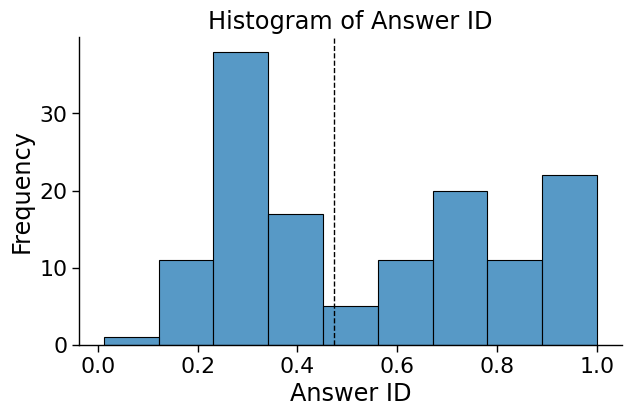

In [6]:
with sns.plotting_context('paper', font_scale = 1.8):

    ### Create new plot
    fig, ax = plt.subplots(1, 1, figsize=(7,4))
    fig.patch.set_alpha(1)

    sns.despine() #bottom=True, left=True

    sns.histplot(behavior_filt['answerID']) #, binwidth=1, binrange=(0.5, 5.5), kde=False)

    # add xline at median
    plt.axvline(behavior_filt['answerID'].median(), color='black', linestyle='dashed', linewidth=1)

    plt.xlabel('Answer ID')
    plt.ylabel('Frequency')
    plt.title('Histogram of Answer ID')
    plt.show()

C:\Users\Lukas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
C:\Users\Lukas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
C:\Users\Lukas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\P

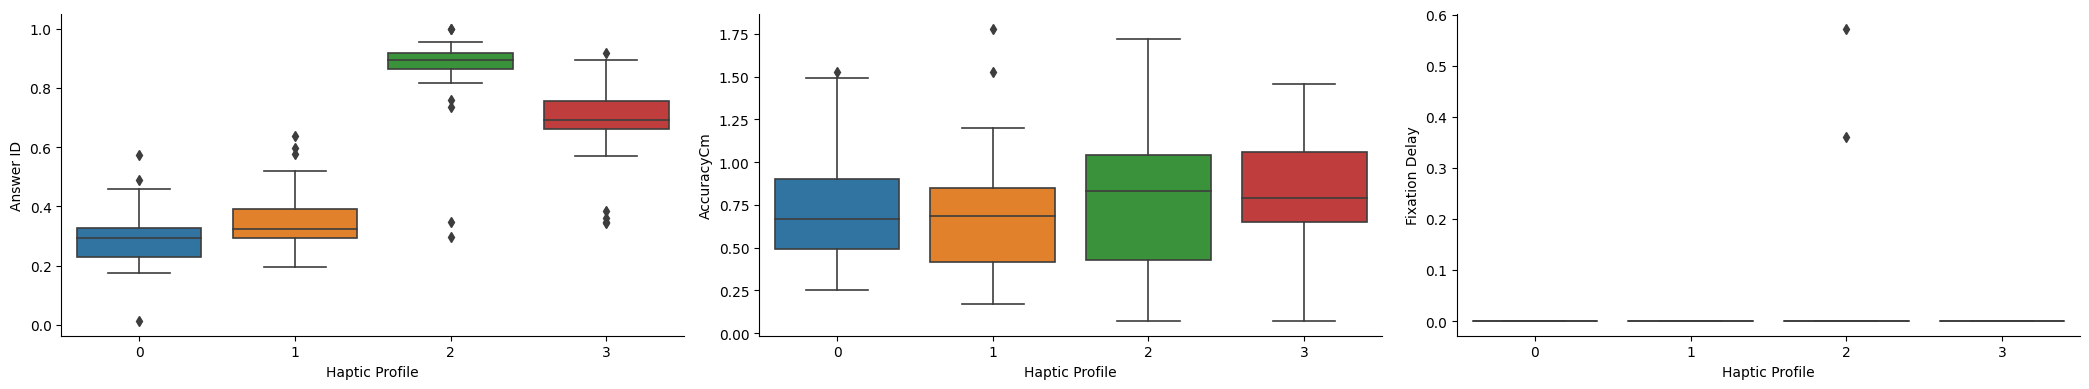

In [7]:
# Define the order for the hapticProfile categories
haptic_order = sorted(behavior['hapticProfile'].unique())

# Convert the hapticProfile column to a categorical type with the specified order
behavior['hapticProfile'] = pd.Categorical(behavior['hapticProfile'], categories=haptic_order, ordered=True)

fig, axs = plt.subplots(1, 3, figsize=(21, 4))
fig.patch.set_alpha(1)

with sns.plotting_context('paper', font_scale=1.8):
    sns.despine()
    sns.boxplot(x='hapticProfile', y='answerID', data=behavior, ax=axs[0])
    axs[0].set_xlabel('Haptic Profile')
    axs[0].set_ylabel('Answer ID')

with sns.plotting_context('paper', font_scale=1.8):
    sns.despine()
    sns.boxplot(x='hapticProfile', y='AccuracyCm', data=behavior, ax=axs[1])
    axs[1].set_xlabel('Haptic Profile')
    axs[1].set_ylabel('AccuracyCm')

with sns.plotting_context('paper', font_scale=1.8):
    sns.despine()
    sns.boxplot(x='hapticProfile', y='fix_delay', data=behavior, ax=axs[2])
    axs[2].set_xlabel('Haptic Profile')
    axs[2].set_ylabel('Fixation Delay')

plt.tight_layout()
plt.show()


# Neuroadaptive Haptics BCI Training

In [8]:
# load data
erp = scipy.io.loadmat(path+os.sep+pID+os.sep+'erp.mat')['erp']
gaze = scipy.io.loadmat(path+os.sep+pID+os.sep+'gaze.mat')['gaze']
hand_motion = scipy.io.loadmat(path+os.sep+pID+os.sep+'hand_motion.mat')['hand_motion']

### Signal Processing

In [9]:
erp = bandpass_filter_fft(erp, .1, 15, 250)

# Gaze
gaze_vel = np.zeros((gaze.shape[1], gaze.shape[2]))
# Calculate the velocity for each trial
for i in range(gaze.shape[2]):
    gaze_vel[:, i] = calculate_velocity(gaze[:, :, i])
# remove invalid samples
for i in range(gaze.shape[2]):
    gaze_vel[:, i] = gaze_remove_invalid_samples(gaze_vel[:,i], gaze[-1,:,i])

# Hand motion
hand_vel = np.zeros((hand_motion.shape[1], hand_motion.shape[2]))
# Calculate the velocity for each trial
for i in range(hand_motion.shape[2]):
    hand_vel[:, i] = calculate_velocity(hand_motion[:, :, i])
# add a singleton dim in 1st place for hand_vel
hand_vel = np.expand_dims(hand_vel, axis=0)
# Apply the bandpass filter to the ERP data
hand_vel = bandpass_filter_fft(hand_vel, .1, 15, 250)
# drop singleton dim
hand_vel = np.squeeze(hand_vel, axis=0)

## Select Data and Assign to Classes

In [10]:
# Simplest approach: select indeces in behavior where answerID is > mean
# this will work with values obtained from a continuous slider in VR where a clear split at the median is possible

high = behavior[behavior['answerID'] > behavior['answerID'].median()].index
low = behavior[behavior['answerID'] < behavior['answerID'].median()].index

## Plots

### EEG

C:\Users\Lukas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Lukas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Lukas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in 

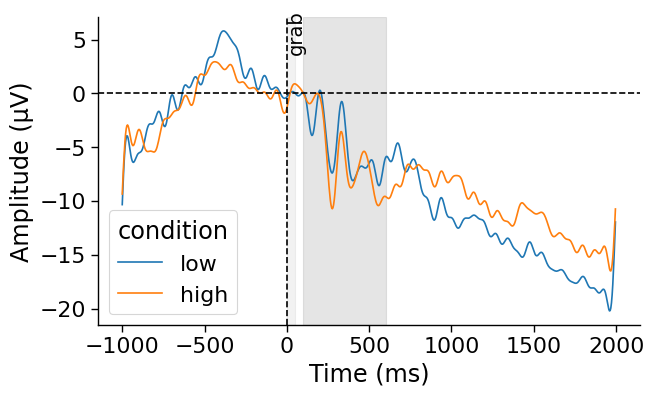

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# erp low
erp_low = erp[:,:,low]
# erp high
erp_high = erp[:,:,high]

plot_erp_low = np.mean(erp_low[4,:,:], axis=1)
plot_erp_high = np.mean(erp_high[4,:,:], axis=1)

erp_baseline_tw = np.arange(250, 262)

# ! fix for final correct baseline correction -> however this is just for plot
plot_erp_low = plot_erp_low - np.mean(plot_erp_low[erp_baseline_tw])
plot_erp_high = plot_erp_high - np.mean(plot_erp_high[erp_baseline_tw])

# merge both conditions
df = pd.DataFrame()
# voltage vector
df['low'] = plot_erp_low
df['high'] = plot_erp_high

# melt
df = pd.melt(df, value_vars=['low', 'high'], var_name='condition', value_name='voltage')

# time vector
df['time'] = np.tile(np.arange(0, len(plot_erp_low)),2)# - 50
df['time'] = (df['time'] * 1/250 * 1000) - 1000

with sns.plotting_context('paper', font_scale = 1.8):

    ### Create new plot
    fig, ax = plt.subplots(1, 1, figsize=(7,4))
    fig.patch.set_alpha(1)

    sns.despine() #bottom=True, left=True

    # sns.lineplot(x='time', y='voltage', hue='condition', style='control', data=df, ax=ax, errorbar='ci')
    sns.lineplot(x='time', y='voltage', hue='condition', data=df, ax=ax, errorbar='ci')
    # sns.lineplot(x='time', y='voltage', hue='control', data=df, ax=ax, errorbar='ci')

    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Amplitude (μV)')

    # xline at 0 with text label 's'
    ax.axvline(0, color='black', linestyle='--')
    ax.text(.1, 4, 'grab', fontsize=14, rotation=90)

    # yline at 0
    ax.axhline(0, color='black', linestyle='--')

    # mark area of feature extraction add a grey background to the y axis range 100 - 300ms
    ax.axvspan(100, 600, color='grey', alpha=0.2, label='features')
    ax.axvspan(0, 50, color='grey', alpha=0.1, label='baseline')

    # move legend to the right
    # ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    # save as eps
    # plt.tight_layout()
    # plt.savefig('/Users/lukasgehrke/Desktop/erp_diff.pdf', format='pdf', dpi=300)

### Motion

C:\Users\Lukas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Lukas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Lukas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in 

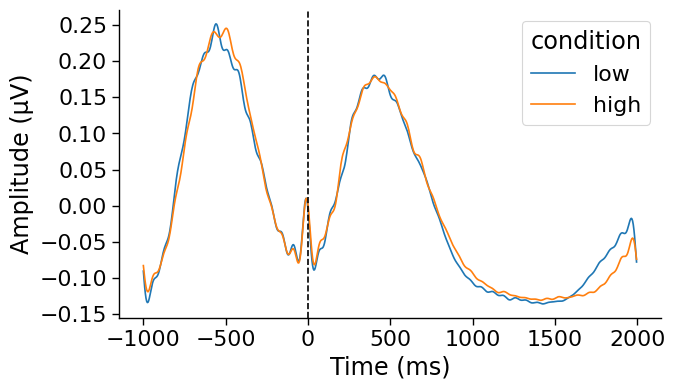

In [12]:
# erp low
erp_low = hand_vel[:,low].mean(axis=1)
# erp high
erp_high = hand_vel[:,high].mean(axis=1)

# merge both conditions
df = pd.DataFrame()
# voltage vector
df['low'] = erp_low
df['high'] = erp_high

# melt
df = pd.melt(df, value_vars=['low', 'high'], var_name='condition', value_name='voltage')

# time vector
df['time'] = np.tile(np.arange(0, len(erp_low)),2)# - 50
df['time'] = (df['time'] * 1/250 * 1000) - 1000

with sns.plotting_context('paper', font_scale = 1.8):

    ### Create new plot
    fig, ax = plt.subplots(1, 1, figsize=(7,4))
    fig.patch.set_alpha(1)

    sns.despine() #bottom=True, left=True

    # sns.lineplot(x='time', y='voltage', hue='condition', style='control', data=df, ax=ax, errorbar='ci')
    sns.lineplot(x='time', y='voltage', hue='condition', data=df, ax=ax, errorbar='ci')
    # sns.lineplot(x='time', y='voltage', hue='control', data=df, ax=ax, errorbar='ci')

    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Amplitude (μV)')

    # xline at 0 with text label 's'
    ax.axvline(0, color='black', linestyle='--')
    # ax.text(-5, .1, 'grab', fontsize=14, rotation=90)

    # yline at 0
    # ax.axhline(0, color='black', linestyle='--')

    # ! mark area of feature extraction add a grey background to the y axis range 100 - 300ms
    # ax.axvspan(50, 450, color='grey', alpha=0.2, label='features')
    # ax.axvspan(0, 50, color='grey', alpha=0.1, label='baseline')

    # move legend to the right
    # ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    # save as eps
    # plt.tight_layout()
    # plt.savefig('/Users/lukasgehrke/Desktop/erp_diff.pdf', format='pdf', dpi=300)

### EYE Tracking

### Fixations

In [13]:
# fixation_low = np.array(behavior.loc[low, 'fix_delay']).reshape(1, -1)
# fixation_high = np.array(behavior.loc[high, 'fix_delay']).reshape(1, -1)

# data = np.concatenate((fixation_low, fixation_high), axis = 1).T
# low_class = np.zeros((fixation_low.shape[1], 1))
# high_class = np.ones((fixation_high.shape[1], 1))
# classes = np.concatenate((low_class, high_class)).ravel()

# data_to_plot = pd.DataFrame(data)
# data_to_plot['Condition'] = classes
# # rename zeros in Condition to low and ones to high
# data_to_plot['Condition'] = data_to_plot['Condition'].replace({0: 'low', 1: 'high'})
# data_to_plot = data_to_plot.melt(id_vars = 'Condition', value_name = 'amplitude')

# import seaborn as sns
# import matplotlib.pyplot as plt

# with sns.plotting_context('paper', font_scale = 1.8):

#     ### Create new plot
#     fig, ax = plt.subplots(1, 1, figsize=(5,4))
#     fig.patch.set_alpha(1)

#     sns.despine() #bottom=True, left=True

#     sns.histplot(x="amplitude", hue="Condition", data=data_to_plot, kde=True, fill=True, stat="density", legend=True)

#     # xlabel
#     plt.xlabel('Time to first target fixation (ms)')


# Compute Features

In [14]:
sample_event = 250
data_selection = 144 # 8 windows with 12 samples each
samples_of_int = np.arange(sample_event, sample_event+data_selection)

### ERPs

In [15]:
# erps = bandpass_filter_fft(erp, .1, 15, 250)

erp_selected = erp[:,samples_of_int,:]
erp_selected = erp_selected.reshape(erp_selected.shape[0], 12, 12, erp_selected.shape[2])
erp_selected = np.mean(erp_selected, axis=2)
baseline = erp_selected[:,0,:]
erp_corrected = erp_selected - baseline[:,np.newaxis,:]
erp_low = erp_corrected[:,:,low]
erp_high = erp_corrected[:,:,high]

### Spectra

In [16]:
# from scipy.stats import ttest_rel

# spec = erp[:,:,:]
# erp_low_uncorrected = spec[:,:,low]
# erp_high_uncorrected = spec[:,:,high]

# fs = 250.0  # Sampling frequency in Hz
# frequency_bands = {
#     'delta': (1, 4),
#     'theta': (4, 8),
#     'alpha': (8, 12),
#     'beta': (12, 30),
#     'gamma': (30, 45)
# }

# # Calculate power spectra for each frequency band
# power_spectra_low = {}
# power_spectra_high = {}
# for band, (lowcut, highcut) in frequency_bands.items():
#     tmp = average_power_fft(erp_low_uncorrected, lowcut, highcut, fs)
#     tmp = tmp[:,samples_of_int,:]
#     tmp = tmp.reshape(tmp.shape[0], 12, 12, tmp.shape[2])
#     power_spectra_low[band] = np.mean(tmp, axis=2)

#     tmp = average_power_fft(erp_high_uncorrected, lowcut, highcut, fs)
#     tmp = tmp[:,samples_of_int,:]
#     tmp = tmp.reshape(tmp.shape[0], 12, 12, tmp.shape[2])
#     power_spectra_high[band] = np.mean(tmp, axis=2)

# # Perform paired t-test for each feature
# t_stats = {}
# p_values = {}
# for band in frequency_bands.keys():
#     t_stats[band] = np.zeros((64, 12, 1))
#     p_values[band] = np.zeros((64, 12, 1))
#     for ch in range(64):
#         for tw in range(12):
#             t_stat, p_val = ttest_rel(power_spectra_low[band][ch, tw, :], power_spectra_high[band][ch, tw, :])
#             t_stats[band][ch] = np.abs(t_stat)
#             p_values[band][ch] = p_val

# # Flatten the t-statistics and sort them
# t_stats_flat_spec = {band: t_stats[band].flatten() for band in frequency_bands.keys()}
# sorted_indices = {band: np.argsort(t_stats_flat_spec[band])[::-1] for band in frequency_bands.keys()}

# # Select the top 10 most discriminative features
# top_features_indices = {band: sorted_indices[band][:10] for band in frequency_bands.keys()}

# # Convert the flat indices back to 2D indices (channel, time window)
# top_features_spec = {band: [(idx // len(samples_of_int), idx % len(samples_of_int)) for idx in top_features_indices[band]] for band in frequency_bands.keys()}

# # Example output
# for band in frequency_bands.keys():
#     print(f"Top features for {band} band:", top_features_spec[band])

C:\Users\Lukas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Lukas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Lukas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values t

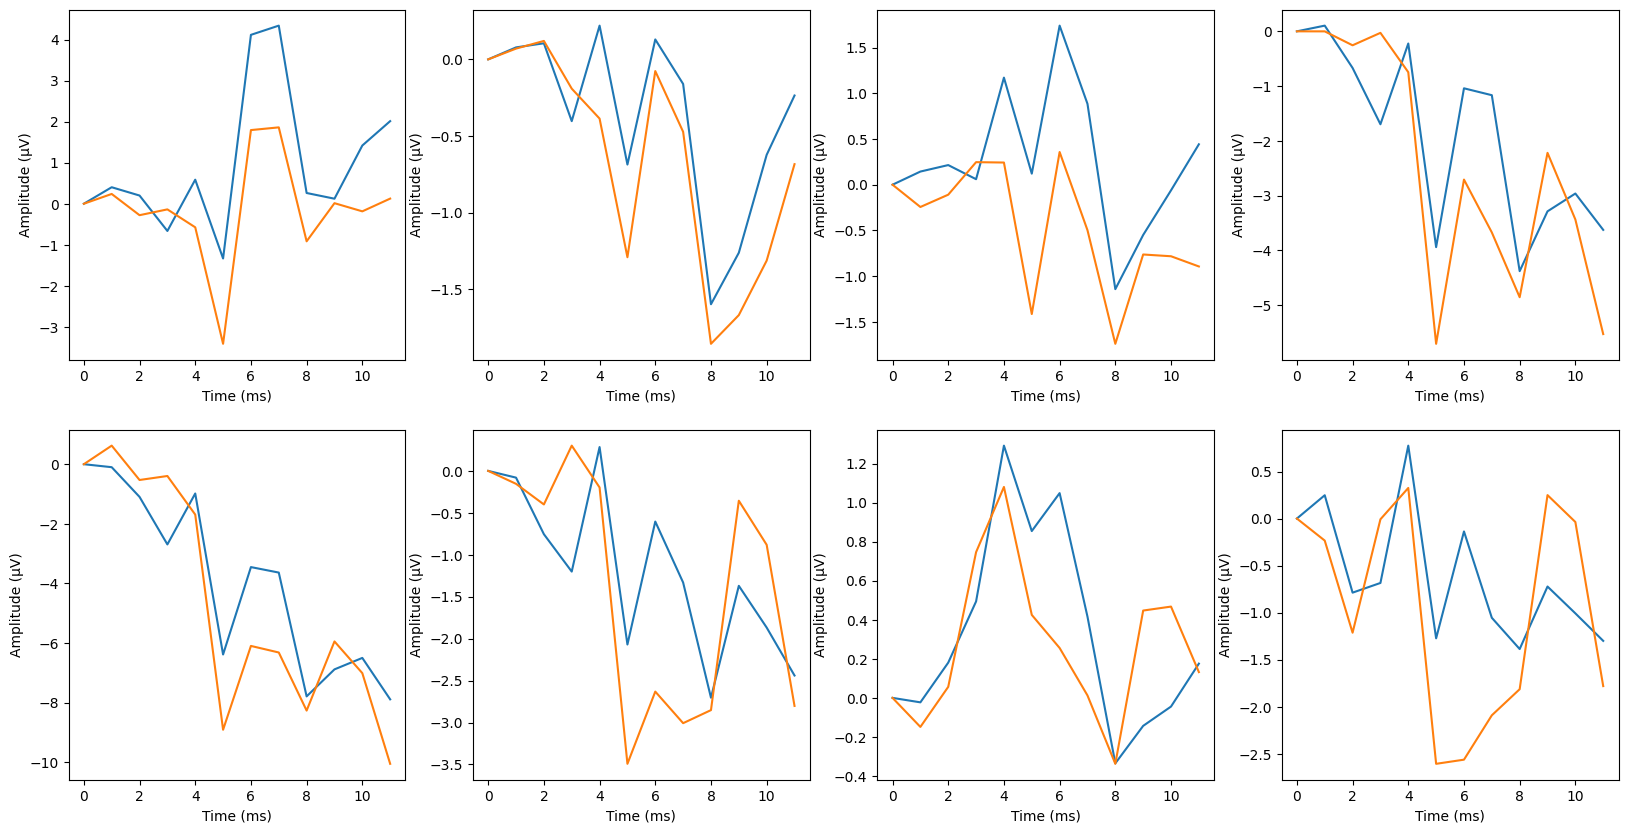

In [17]:
erp_low_plot = np.mean(erp_low, axis=2)
erp_high_plot = np.mean(erp_high, axis=2)

# plot them
fig, axs = plt.subplots(2, 4, figsize=(20, 10))
fig.patch.set_alpha(1)

for i, ax in enumerate(axs.flat):
    sns.lineplot(data=erp_low_plot[i], ax=ax, errorbar='sd')
    sns.lineplot(data=erp_high_plot[i], ax=ax, errorbar='sd')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Amplitude (μV)')

### Channel Selection

In [18]:
# # Compute the mean ERP for each class
# mean_erp_low = np.mean(erp_low, axis=2)
# mean_erp_high = np.mean(erp_high, axis=2)

# # Subtract the mean ERP of the high class from the mean ERP of the low class and square the result
# erp_diff_squared = (mean_erp_low - mean_erp_high) ** 2

# # Compute the mean over the 12 windows for each channel
# erp_diff_mean = np.mean(erp_diff_squared, axis=1)

# # Sort the channels by the absolute differences
# sorted_channels = np.argsort(np.abs(erp_diff_mean))[::-1]

# # Print the sorted channels
# print("Sorted channels by differences:", sorted_channels)

# # select the top 10 channels
# top_channels = sorted_channels[:10] # needs to be saved for real-time application

# # save the top channels
# with open(path+os.sep+pID+os.sep+'top_channels.json', 'w') as f:
#     json.dump(top_channels.tolist(), f)

### Hand motion

In [19]:
hand_vel_selected = hand_vel[samples_of_int,:]

# hand_vel_selected = hand_vel_selected.reshape(12, 12, hand_vel_selected.shape[1])
# hand_vel_selected = np.mean(hand_vel_selected, axis=1)
# baseline = hand_vel_selected[:,0,:]
# erp_corrected = hand_vel_selected - baseline[:,np.newaxis,:]

hand_vel_low = hand_vel_selected[:,low]
hand_vel_high = hand_vel_selected[:,high]

C:\Users\Lukas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Lukas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Lukas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values t

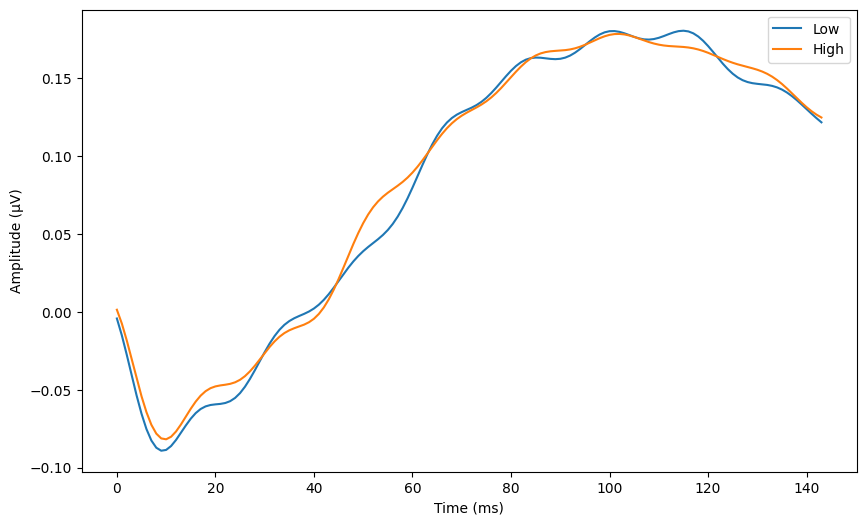

In [20]:
hand_vel_low_plot = np.mean(hand_vel_low, axis=1)
hand_vel_high_plot = np.mean(hand_vel_high, axis=1)

# plot them
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_alpha(1)

sns.lineplot(data=hand_vel_low_plot, ax=ax, errorbar='sd', label='Low')
sns.lineplot(data=hand_vel_high_plot, ax=ax, errorbar='sd', label='High')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Amplitude (μV)')
ax.legend()
plt.show()

### Eye Tracking

In [21]:
# EYE - gaze velocity? fixation frequency per second?


# EYE - time to first target fixation
fixation_low = np.array(behavior.loc[low, 'fix_delay']).reshape(1, -1)
fixation_high = np.array(behavior.loc[high, 'fix_delay']).reshape(1, -1)

# Fit Model and Cross-validate

### Feature Vector

In [22]:
from scipy.stats import ttest_rel

erp_low = erp_low[:,1:,:]
erp_low = np.transpose(erp_low, (2, 0, 1))
erp_high = erp_high[:,1:,:]
erp_high = np.transpose(erp_high, (2, 0, 1))

# Compute the t-statistic for each channel and time window
t_stats = np.zeros((erp_low.shape[1], erp_low.shape[2]))
p_values = np.zeros((erp_low.shape[1], erp_low.shape[2]))

for ch in range(erp_low.shape[1]):
    for tw in range(erp_low.shape[2]):
        t_stat, p_val = ttest_rel(erp_low[:, ch, tw], erp_high[:, ch, tw])
        t_stats[ch, tw] = np.abs(t_stat)
        p_values[ch, tw] = p_val

# Flatten the t-statistics and sort them
t_stats_flat_erp = t_stats.flatten()
sorted_indices = np.argsort(t_stats_flat_erp)[::-1]  # Sort in descending order

# Select the top 50 features, what is the best metric here? - iterate?
# top_features_indices = sorted_indices[:50]

# # Convert the flat indices back to 2D indices (channel, time window)
# top_features_erp = [(idx // erp_low.shape[2], idx % erp_low.shape[2]) for idx in sorted_indices]

# # Construct the feature vectors by keeping the single trials
# features_low = np.zeros((erp_low.shape[0], len(top_features_erp)))
# features_high = np.zeros((erp_high.shape[0], len(top_features_erp)))

# for i, (ch, tw) in enumerate(top_features_erp):
#     features_low[:, i] = erp_low[:, ch, tw]
#     features_high[:, i] = erp_high[:, ch, tw]

# print("Feature vector shape for class 1:", features_low.shape)
# print("Feature vector shape for class 2:", features_high.shape)

# # transpose
# features_low = features_low.T
# features_high = features_high.T

### Join Spec and ERP

In [23]:
# # Combine ERP and spectral features
# combined_t_stats = np.concatenate([t_stats_flat_erp] + [t_stats_flat_spec[band] for band in frequency_bands.keys()])
# combined_sorted_indices = np.argsort(combined_t_stats)[::-1]

# # Select the top N combined features
# N = 50
# top_combined_indices = combined_sorted_indices[:N]

# # Determine if the feature is from ERP or spectral data
# erp_feature_count = len(t_stats_flat_erp)
# top_combined_features = []
# for idx in top_combined_indices:
#     if idx < erp_feature_count:
#         ch, tw = idx // erp_low.shape[2], idx % erp_low.shape[2]
#         top_combined_features.append(('erp', ch, tw))
#     else:
#         idx -= erp_feature_count
#         for band in frequency_bands.keys():
#             if idx < len(t_stats_flat_spec[band]):
#                 ch, tw = idx // len(samples_of_int), idx % len(samples_of_int)
#                 top_combined_features.append((band, ch, tw))
#                 break
#             idx -= len(t_stats_flat_spec[band])

# # Construct the feature vectors by keeping the single trials
# feature_vector_class1 = np.zeros((erp_low.shape[0], N))
# features_high = np.zeros((erp_high.shape[0], N))

# for i, (source, ch, tw) in enumerate(top_combined_features):
#     if source == 'erp':
#         feature_vector_class1[:, i] = erp_low[:, ch, tw]
#         features_high[:, i] = erp_high[:, ch, tw]
#     else:
#         feature_vector_class1[:, i] = power_spectra_low[source][ch, tw, :].flatten()
#         features_high[:, i] = power_spectra_high[source][ch, tw, :].flatten()

# print("Feature vector shape for class 1:", feature_vector_class1.shape)
# print("Feature vector shape for class 2:", features_high.shape)

In [24]:
# # drop baseline dim
# # erp_low = erp_low[top_channels,2:,:]
# # erp_high = erp_high[top_channels,2:,:]

# erp_low = erp_low[top_channels,2:8,:]
# erp_high = erp_high[top_channels,2:8,:]

# erp_low_flattened = erp_low.reshape(-1, erp_low.shape[-1])
# erp_high_flattened = erp_high.reshape(-1, erp_high.shape[-1])

# hand_vel_low = np.max(hand_vel_low, axis=0).reshape(1, -1)
# hand_vel_high = np.max(hand_vel_high, axis=0).reshape(1, -1)

# # concat all low features
# #features_low = np.concatenate((erp_low_flattened, fixation_low), axis=0)
# #features_low = np.concatenate((erp_low_flattened, hand_vel_low, fixation_low), axis=0)
# features_low = erp_low_flattened
# # concat all high features
# #features_high = np.concatenate((erp_high_flattened, fixation_high), axis=0)
# #features_high = np.concatenate((erp_high_flattened, hand_vel_high, fixation_high), axis=0)
# features_high = erp_high_flattened

# features_low = feature_vector_class1.T
# features_high = features_high.T

### Train-Test Split

In [25]:
best_cv_score = -np.inf
best_set = None
best_clf = None
best_scaler = None
best_lda_scores = None

for set in range(10, 100, 5):
    top_features_erp = [(idx // erp_low.shape[2], idx % erp_low.shape[2]) for idx in sorted_indices[:set]]

    # Construct the feature vectors by keeping the single trials
    features_low = np.zeros((erp_low.shape[0], len(top_features_erp)))
    features_high = np.zeros((erp_high.shape[0], len(top_features_erp)))

    for i, (ch, tw) in enumerate(top_features_erp):
        features_low[:, i] = erp_low[:, ch, tw]
        features_high[:, i] = erp_high[:, ch, tw]

    # print("Feature vector shape for class 1:", features_low.shape)
    # print("Feature vector shape for class 2:", features_high.shape)

    # transpose
    features_low = features_low.T
    features_high = features_high.T

    data = np.concatenate((features_low, features_high), axis=1).T
    low_class = np.zeros((features_low.shape[1], 1))
    high_class = np.ones((features_high.shape[1], 1))
    classes = np.concatenate((low_class, high_class)).ravel()

    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    data = scaler.fit_transform(data)

    # generate a train-test split
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(data, classes, test_size=0.2, random_state=42)

    clf = LDA(solver='eigen', shrinkage='auto')

    # Perform cross-validation on the training data
    cv_scores = cross_val_score(clf, X_train, y_train)
    mean_cv_score = np.mean(cv_scores)
    print(f"Mean cross-validation score for set {set}: {mean_cv_score}")

    if mean_cv_score > best_cv_score:

        # save top_features_erp
        top_features_erp_list = [(int(t[0]), int(t[1])) for t in top_features_erp]
        with open(path + os.sep + pID + os.sep + 'top_features_erp.json', 'w') as f:
            json.dump(top_features_erp_list, f)
        print(top_features_erp_list)
        
        best_data = data
        best_cv_score = mean_cv_score
        best_set = set
        best_clf = clf
        best_scaler = scaler
        best_lda_scores = clf.fit(X_train, y_train).transform(X_test)

# Save the best model and parameters
if best_clf is not None:

    print(best_cv_score)
    print(best_set)

    pickle.dump(best_scaler, open(path + os.sep + pID + os.sep + 'scaler.sav', 'wb'))
    with open(path + os.sep + pID + os.sep + 'lda_scores.json', 'w') as f:
        json.dump(best_lda_scores.tolist(), f)
    best_clf.fit(best_data, classes)
    filename = path + os.sep + pID + os.sep + 'model.sav'
    pickle.dump(best_clf, open(filename, 'wb'))

    # Save BCI params
    target_class = 1
    mean_fix_delay = np.mean(behavior['fix_delay'])


Mean cross-validation score for set 10: 0.5458874458874459
[(20, 9), (25, 10), (25, 9), (20, 10), (58, 9), (59, 8), (59, 9), (10, 5), (20, 7), (7, 5)]
Mean cross-validation score for set 15: 0.5822510822510822
[(20, 9), (25, 10), (25, 9), (20, 10), (58, 9), (59, 8), (59, 9), (10, 5), (20, 7), (7, 5), (29, 9), (25, 7), (20, 5), (55, 10), (57, 9)]
Mean cross-validation score for set 20: 0.5822510822510822
Mean cross-validation score for set 25: 0.563203463203463
Mean cross-validation score for set 30: 0.6476190476190476
[(20, 9), (25, 10), (25, 9), (20, 10), (58, 9), (59, 8), (59, 9), (10, 5), (20, 7), (7, 5), (29, 9), (25, 7), (20, 5), (55, 10), (57, 9), (8, 4), (55, 9), (58, 7), (8, 5), (29, 8), (54, 9), (42, 5), (20, 4), (25, 5), (58, 10), (40, 5), (27, 9), (57, 8), (30, 2), (25, 6)]
Mean cross-validation score for set 35: 0.629004329004329
Mean cross-validation score for set 40: 0.6194805194805195
Mean cross-validation score for set 45: 0.6666666666666667
[(20, 9), (25, 10), (25, 9),

### Model Analyses

#### LDA Scores left out data

C:\Users\Lukas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Lukas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


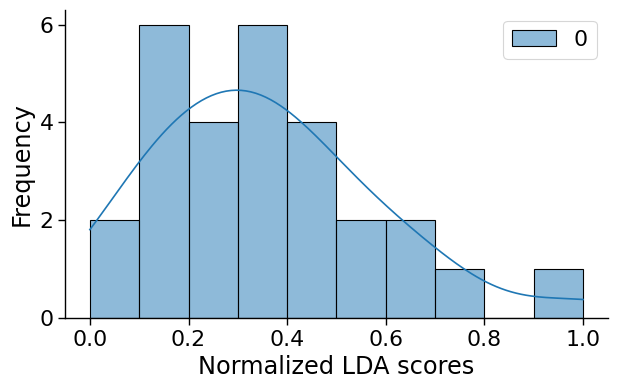

In [26]:
# min max scaling
normalized_lda_scores = (best_lda_scores - best_lda_scores.min()) / (best_lda_scores.max() - best_lda_scores.min())

with sns.plotting_context('paper', font_scale = 1.8):

    ### Create new plot
    fig, ax = plt.subplots(1, 1, figsize=(7,4))
    fig.patch.set_alpha(1)

    sns.despine() #bottom=True, left=True

    sns.histplot(normalized_lda_scores, binwidth=0.1, kde=True, ax=ax)
    # xline boundaries
    # ax.axvline(boundary_low, color='black', linestyle='--')
    # ax.axvline(boundary_high, color='black', linestyle='--')
    plt.xlabel('Normalized LDA scores')
    plt.ylabel('Frequency')
    # plt.title('Histogram of decision function scores')
    plt.show()


In [27]:
# calculate tpr, fpr, f1, precision, recall, accuracy
from sklearn.metrics import confusion_matrix

y_pred = best_clf.predict(best_data)
predictions_prob = best_clf.predict_proba(best_data)

cm = confusion_matrix(classes, y_pred)

tn, fp, fn, tp = cm.ravel()

tpr = tp / (tp + fn)
fpr = fp / (fp + tn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)
accuracy = (tp + tn) / (tp + tn + fp + fn)

# print these all
print(f"True positive rate: {tpr}")
print(f"False positive rate: {fpr}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")
print(f"Accuracy: {accuracy}")
print("Predicted classes: ", y_pred)
print("Actual classes:    ", classes)
print("Confusion matrix: ")
print(cm)


True positive rate: 0.7794117647058824
False positive rate: 0.14705882352941177
Precision: 0.8412698412698413
Recall: 0.7794117647058824
F1: 0.8091603053435115
Accuracy: 0.8161764705882353
Predicted classes:  [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0.
 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0.
 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1.
 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 0. 1. 1. 0. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1.
 0. 1. 1. 1. 0. 0. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1.]
Actual classes:     [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 

#### ROC

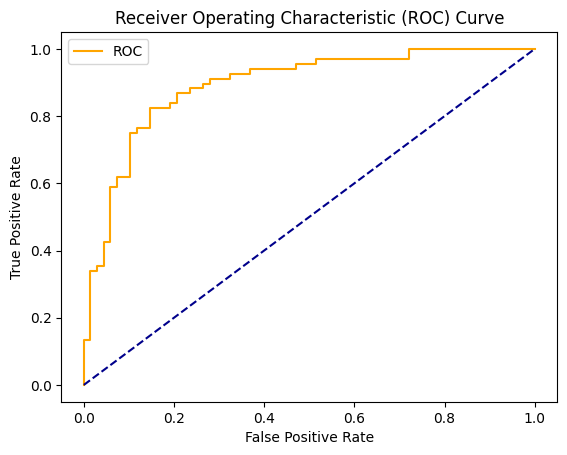

F1 Score: 0.8091603053435115
{'target_class': 1, 'mean_fix_delay': 0.006852941176470588, 'f1': 0.8091603053435115, 'accuracy': 0.8161764705882353, 'best_cv_score': 0.7121212121212122, 'best_set': 60}


In [28]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc_curve(fpr, tpr):
    plt.plot(fpr, tpr, color='orange', label='ROC')
    plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()
    plt.show()

def interp_roc_curve(true, score, by ='fp', byval = np.linspace(0,1,101)):
    fp, tp, th =  roc_curve(true, score)
    data = {'fp': fp, 'tp': tp, 'th': th}
    interpData = {}
    for k,v in data.items():
        if k==by:
            interpData[k] = byval
        else:
            interpData[k] = np.interp(byval, data[by], data[k])
    roc = pd.DataFrame.from_dict(interpData)
    return(roc)

roc = interp_roc_curve(classes, predictions_prob[:,1])

false_positive_rate, recall, thresholds = roc_curve(classes, predictions_prob[:,1])

np.savetxt(path+os.sep+pID+os.sep+'fpr.csv', roc.fp, delimiter=',')
np.savetxt(path+os.sep+pID+os.sep+'recall.csv', roc.tp, delimiter=',')

roc_auc = auc(false_positive_rate, recall)
plot_roc_curve(false_positive_rate, recall)

from sklearn.metrics import f1_score
f1 = f1_score(classes, y_pred)
print("F1 Score: "+ str(f1_score(classes, y_pred)))

# bci_params = dict(((k, eval(k)) for k in ('nr_feats', 'target_class', 'mean_fix_delay', 'tpr', 'fpr', 'precision', 'recall', 'f1', 'accuracy')))
bci_params = dict(((k, eval(k)) for k in ('target_class', 'mean_fix_delay', 'f1', 'accuracy', 'best_cv_score', 'best_set')))
with open(path + os.sep + pID + os.sep + 'bci_params.json', 'w') as f:
    json.dump(bci_params, f)
print(bci_params)